# EXXA4 — Image-Based Test: Autoencoder

Author: Abdellah Elmlih | GSoC 2026, ML4Sci

Convolutional autoencoder for ALMA protoplanetary disk images with an accessible 128-d latent space. No skip connections — the latent vector alone is enough to reconstruct the image, so `encode_image()` and `decode_latent()` give meaningful results.


## Setup & Data


In [1]:
%%capture
!pip install astropy gdown torch torchvision pytorch-msssim matplotlib seaborn tqdm

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os, json, random, warnings
from pathlib import Path
from astropy.io import fits
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pytorch_msssim import ms_ssim
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED); random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [3]:

DATA_DIR = './continuum_data_subset'


fits_files = sorted(glob.glob(os.path.join(DATA_DIR, '**/*.fits'), recursive=True))

if not fits_files:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        DRIVE_PATH = '/content/drive/MyDrive/continuum_data_subset'
        if os.path.exists(DRIVE_PATH):
            DATA_DIR = DRIVE_PATH
            print(f'Using Drive data: {DRIVE_PATH}')
        else:
            print('Drive mounted but folder not found.')
            print('Please:')
            print('  1. Open: https://drive.google.com/drive/folders/1VkS3RHkAjiKjJ6DnZmEKZ_nUv4w6pz7P')
            print('  2. Right-click the folder -> "Add shortcut to Drive" -> "My Drive"')
            print('  3. Re-run this cell')
    except ImportError:

        print('Not on Colab. Attempting gdown download...')
        import gdown
        os.makedirs(DATA_DIR, exist_ok=True)
        try:
            gdown.download_folder(
                'https://drive.google.com/drive/folders/1VkS3RHkAjiKjJ6DnZmEKZ_nUv4w6pz7P',
                output=DATA_DIR, quiet=False, use_cookies=False, remaining_ok=True
            )
        except Exception as e:
            print(f'gdown error: {e}')
            print('\nManual download required:')
            print('  1. Go to: https://drive.google.com/drive/folders/1VkS3RHkAjiKjJ6DnZmEKZ_nUv4w6pz7P')
            print('  2. Select all files -> Download (creates .zip)')
            print(f'  3. Extract .fits files into: {os.path.abspath(DATA_DIR)}/')
            print('  4. Re-run this cell')

fits_files = sorted(glob.glob(os.path.join(DATA_DIR, '**/*.fits'), recursive=True))
if not fits_files:
    fits_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.fits')))

if len(fits_files) == 0:
    print('\n No .fits files found yet. Follow the instructions above, then re-run.')
else:
    print(f'\n Found {len(fits_files)} .fits files')
    print(f'  First: {fits_files[0]}')
    print(f'  Last:  {fits_files[-1]}')



 Found 38 .fits files
  First: ./continuum_data_subset\planet0_00226_1250.fits
  Last:  ./continuum_data_subset\planet9_00916_1250.fits


In [4]:
IMG_SIZE = 128

def load_fits_image(filepath, layer=0):

    with fits.open(filepath) as hdul:
        data = hdul[0].data
        
        data = np.squeeze(data)
        if data.ndim == 3:
            return data[layer].astype(np.float64)
        elif data.ndim == 2:
            return data.astype(np.float64)
        elif data.ndim == 4:
            return data[layer, 0].astype(np.float64)
        else:
       
            flat = data.reshape(-1, data.shape[-2], data.shape[-1])
            return flat[0].astype(np.float64)


def preprocess_image(image, target_size=IMG_SIZE):

    from scipy.ndimage import zoom as scipy_zoom
    
    img = np.copy(image)
    # Ensure 2D
    img = np.squeeze(img)
    if img.ndim != 2:
        raise ValueError(f'Expected 2D image, got shape {img.shape}')
    
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
    img = np.clip(img, 0, None)

    nonzero = img[img > 0]
    scale = np.median(nonzero) if len(nonzero) > 0 else 1.0
    img = np.arcsinh(img / (scale + 1e-30))
    

    vmin, vmax = img.min(), img.max()
    if vmax > vmin:
        img = (img - vmin) / (vmax - vmin)
    else:
        img = np.zeros_like(img)
    

    h, w = img.shape
    if h != target_size or w != target_size:
        img = scipy_zoom(img, (target_size / h, target_size / w), order=1)
    
    return img.astype(np.float32)


print(f'Loading {len(fits_files)} images...')
images, filenames = [], []
for fp in tqdm(fits_files, desc='Loading'):
    try:
        raw = load_fits_image(fp)
        proc = preprocess_image(raw)
        images.append(proc)
        filenames.append(os.path.basename(fp))
    except Exception as e:
        print(f'  Skip {os.path.basename(fp)}: {e}')

assert len(images) > 0, 'No images loaded! Check the data directory and .fits file format.'
images = np.array(images)
print(f'\nDataset: {images.shape}, range [{images.min():.4f}, {images.max():.4f}]')


Loading 38 images...


Loading:   0%|          | 0/38 [00:00<?, ?it/s]


Dataset: (38, 128, 128), range [0.0000, 0.9923]


## DataLoaders


In [5]:
class DiskDataset(Dataset):
    def __init__(self, images, augment=False):
        self.images = torch.tensor(images, dtype=torch.float32).unsqueeze(1)
        self.augment = augment
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx]
        if self.augment:
            img = torch.rot90(img, random.randint(0,3), dims=[1,2])
            if random.random()>0.5: img = torch.flip(img, dims=[1])
            if random.random()>0.5: img = torch.flip(img, dims=[2])
        return img, idx

n = len(images); n_tr = int(0.8*n); n_va = int(0.1*n); n_te = n - n_tr - n_va
perm = np.random.permutation(n)
train_ds = DiskDataset(images[perm[:n_tr]], augment=True)
val_ds   = DiskDataset(images[perm[n_tr:n_tr+n_va]], augment=False)
test_ds  = DiskDataset(images[perm[n_tr+n_va:]], augment=False)
full_ds  = DiskDataset(images, augment=False)

BS = 16
train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BS, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BS, shuffle=False)
print(f'Train={n_tr}(aug), Val={n_va}, Test={n_te}')

Train=30(aug), Val=3, Test=5


## Architecture

No skip connections. Everything goes through the 128-d bottleneck.


In [6]:
LATENT_DIM = 128

class EncBlock(nn.Module):
    def __init__(self, ci, co):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.GELU(),
            nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.GELU())
        self.pool = nn.MaxPool2d(2, 2)
    def forward(self, x):
        return self.pool(self.conv(x))


class DecBlock(nn.Module):
 
    def __init__(self, ci, co):
        super().__init__()
        self.up = nn.ConvTranspose2d(ci, co, 2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.GELU(),
            nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.GELU())
    def forward(self, x):
        return self.conv(self.up(x))

class DiskAutoencoder(nn.Module):

    def __init__(self, latent_dim=LATENT_DIM, img_size=IMG_SIZE):
        super().__init__()
        self.latent_dim = latent_dim
        sp = img_size // 16
        self.e1 = EncBlock(1, 32)
        self.e2 = EncBlock(32, 64)
        self.e3 = EncBlock(64, 128)
        self.e4 = EncBlock(128, 256)
        flat = 256 * sp * sp
        self.to_z = nn.Sequential(
            nn.Flatten(), nn.Linear(flat, 512), nn.GELU(),
            nn.Dropout(0.1), nn.Linear(512, latent_dim))
        self.from_z = nn.Sequential(
            nn.Linear(latent_dim, 512), nn.GELU(),
            nn.Linear(512, flat), nn.GELU())
        self._sp = sp
        self.d4 = DecBlock(256, 128)
        self.d3 = DecBlock(128, 64)
        self.d2 = DecBlock(64, 32)
        self.d1 = DecBlock(32, 32)
        self.out = nn.Sequential(nn.Conv2d(32, 1, 1), nn.Sigmoid())

    def encode(self, x):
        h = self.e1(x); h = self.e2(h); h = self.e3(h); h = self.e4(h)
        return self.to_z(h)

    def decode(self, z):
        h = self.from_z(z).view(-1, 256, self._sp, self._sp)
        h = self.d4(h); h = self.d3(h); h = self.d2(h); h = self.d1(h)
        return self.out(h)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

    @torch.no_grad()
    def get_latent(self, x):
        self.eval()
        return self.encode(x)


model = DiskAutoencoder().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'DiskAutoencoder: {n_params:,} params, latent_dim={LATENT_DIM}')
print(f'NO skip connections — encode/decode roundtrip is faithful')
with torch.no_grad():
    t = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
    o, z = model(t)
    d = model.decode(z)
    assert t.shape == o.shape, f'Forward: {t.shape} vs {o.shape}'
    assert t.shape == d.shape, f'Standalone: {t.shape} vs {d.shape}'
    print(f'Forward:    {t.shape} -> z{z.shape} -> {o.shape} OK')
    print(f'Standalone: z{z.shape} -> {d.shape} OK')


DiskAutoencoder: 18,682,881 params, latent_dim=128
NO skip connections — encode/decode roundtrip is faithful
Forward:    torch.Size([2, 1, 128, 128]) -> ztorch.Size([2, 128]) -> torch.Size([2, 1, 128, 128]) OK
Standalone: ztorch.Size([2, 128]) -> torch.Size([2, 1, 128, 128]) OK


## Training


In [7]:
N_EPOCHS = 80
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)

def loss_fn(x_hat, x):
    mse = F.mse_loss(x_hat, x)
    try: ssim_l = 1 - ms_ssim(x_hat, x, data_range=1.0, size_average=True, win_size=7, weights=[0.5,0.3,0.2])
    except: ssim_l = torch.tensor(0.0, device=x.device)
    return 0.3*mse + 0.7*ssim_l, mse, ssim_l

best_val = float('inf')
hist = {'tl':[],'vl':[],'tm':[],'vm':[],'ts':[],'vs':[]}
print(f'Training for {N_EPOCHS} epochs (loss = 0.3×MSE + 0.7×(1−MS-SSIM))\n')

for ep in range(1, N_EPOCHS+1):
    model.train(); tl,tm,ts,n = 0,0,0,0
    for imgs, _ in train_loader:
        imgs = imgs.to(DEVICE); optimizer.zero_grad()
        rec, z = model(imgs); loss, ml, sl = loss_fn(rec, imgs)
        loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
        b = imgs.size(0); tl+=loss.item()*b; tm+=ml.item()*b; ts+=sl.item()*b; n+=b
    tl/=n; tm/=n; ts/=n

    model.eval(); vl,vm,vs,nv = 0,0,0,0
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(DEVICE); rec, z = model(imgs); loss, ml, sl = loss_fn(rec, imgs)
            b = imgs.size(0); vl+=loss.item()*b; vm+=ml.item()*b; vs+=sl.item()*b; nv+=b
    vl/=nv; vm/=nv; vs/=nv
    scheduler.step()
    for k,v in zip(['tl','vl','tm','vm','ts','vs'],[tl,vl,tm,vm,ts,vs]): hist[k].append(v)
    if vl < best_val: best_val = vl; torch.save(model.state_dict(), 'best_autoencoder.pt')
    if ep%10==0 or ep==1:
        print(f'Ep {ep:3d}/{N_EPOCHS}  Train: L={tl:.5f} MSE={tm:.5f}  |  Val: L={vl:.5f} MSE={vm:.5f}')

print(f'\nBest val: {best_val:.5f}')
model.load_state_dict(torch.load('best_autoencoder.pt'))

Training for 80 epochs (loss = 0.3×MSE + 0.7×(1−MS-SSIM))

Ep   1/80  Train: L=0.60742 MSE=0.15717  |  Val: L=0.50608 MSE=0.17993
Ep  10/80  Train: L=0.38567 MSE=0.15081  |  Val: L=0.50757 MSE=0.18428
Ep  20/80  Train: L=0.38132 MSE=0.15034  |  Val: L=0.50821 MSE=0.18618
Ep  30/80  Train: L=0.40497 MSE=0.14167  |  Val: L=0.44939 MSE=0.15890
Ep  40/80  Train: L=0.31882 MSE=0.13899  |  Val: L=0.42981 MSE=0.16818
Ep  50/80  Train: L=0.26110 MSE=0.09314  |  Val: L=0.39929 MSE=0.18846
Ep  60/80  Train: L=0.26334 MSE=0.09990  |  Val: L=0.33870 MSE=0.15214
Ep  70/80  Train: L=0.24662 MSE=0.08968  |  Val: L=0.45210 MSE=0.19252
Ep  80/80  Train: L=0.19059 MSE=0.07189  |  Val: L=0.45230 MSE=0.23030

Best val: 0.32251


<All keys matched successfully>

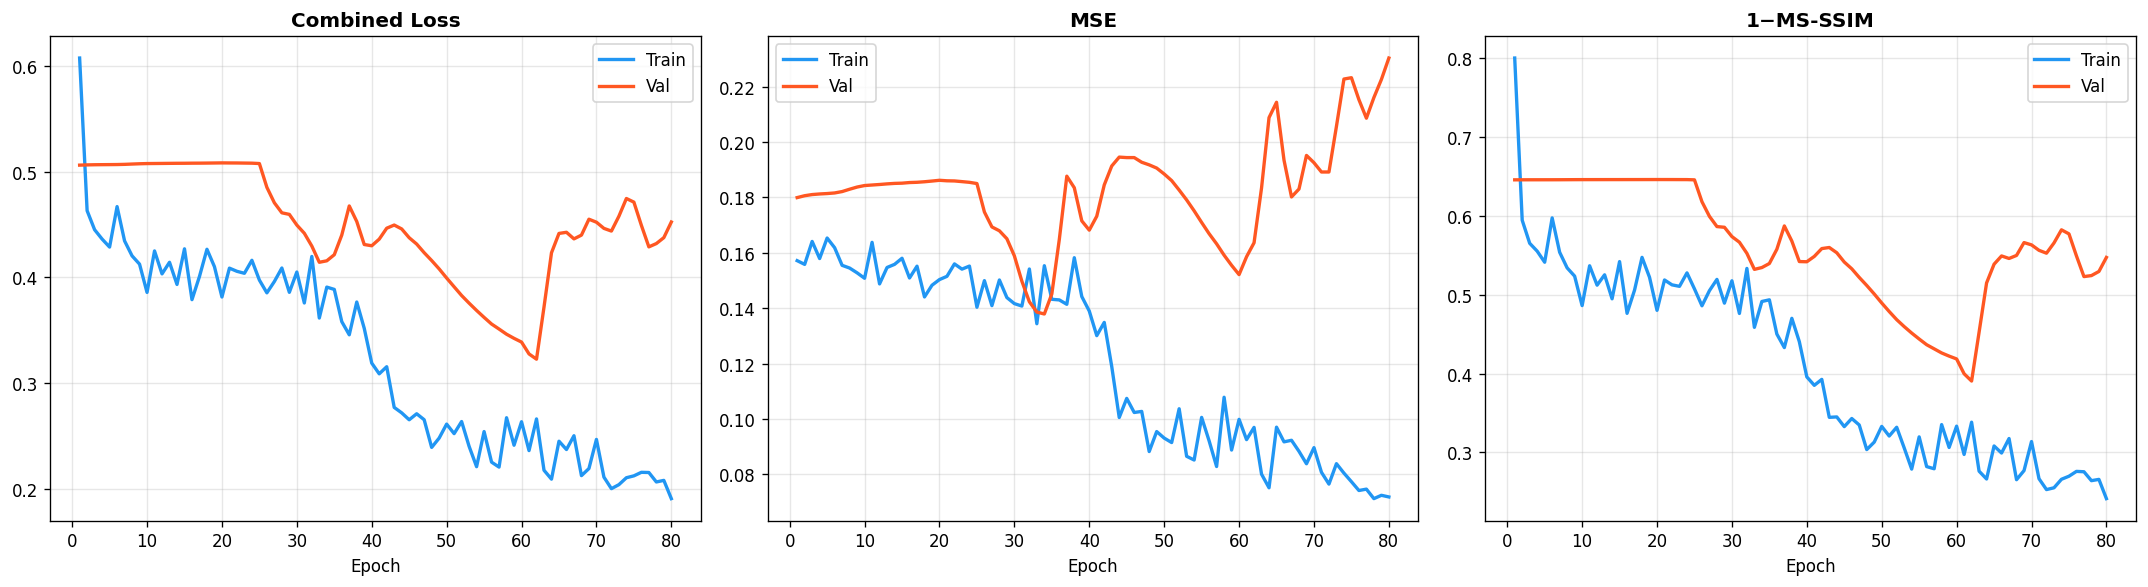

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)
ep = range(1, N_EPOCHS+1)
for ax,(t,v),title in zip(axes,[('tl','vl'),('tm','vm'),('ts','vs')],['Combined Loss','MSE','1−MS-SSIM']):
    ax.plot(ep, hist[t], label='Train', color='#2196F3', lw=2)
    ax.plot(ep, hist[v], label='Val', color='#FF5722', lw=2)
    ax.set_xlabel('Epoch'); ax.set_title(title, weight='bold'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('training_curves.png', dpi=150, bbox_inches='tight'); plt.show()

## Reconstruction Metrics

MSE and MS-SSIM on the test set.


In [9]:
@torch.no_grad()
def compute_metrics(model, loader, device):
    model.eval(); mses, ssims, origs, recs = [], [], [], []
    for imgs, _ in loader:
        imgs = imgs.to(device); rec, z = model(imgs)
        origs.append(imgs.cpu()); recs.append(rec.cpu())
        for j in range(imgs.size(0)):
            o, r = imgs[j:j+1], rec[j:j+1]
            mses.append(F.mse_loss(r,o).item())
            try: ssims.append(ms_ssim(r,o,data_range=1.0,win_size=7,weights=[0.5,0.3,0.2]).item())
            except: ssims.append(float('nan'))
    return {'mse':np.array(mses),'msssim':np.array(ssims),'orig':torch.cat(origs),'rec':torch.cat(recs)}

tm = compute_metrics(model, test_loader, DEVICE)
valid_ssim = tm['msssim'][~np.isnan(tm['msssim'])]

print('='*55)
print('  RECONSTRUCTION METRICS (Test Set)')
print('='*55)
print(f'  MSE     : {tm["mse"].mean():.6f} ± {tm["mse"].std():.6f}')
print(f'  MS-SSIM : {valid_ssim.mean():.6f} ± {valid_ssim.std():.6f}')
print('='*55)

  RECONSTRUCTION METRICS (Test Set)
  MSE     : 0.108642 ± 0.045304
  MS-SSIM : 0.720357 ± 0.053467


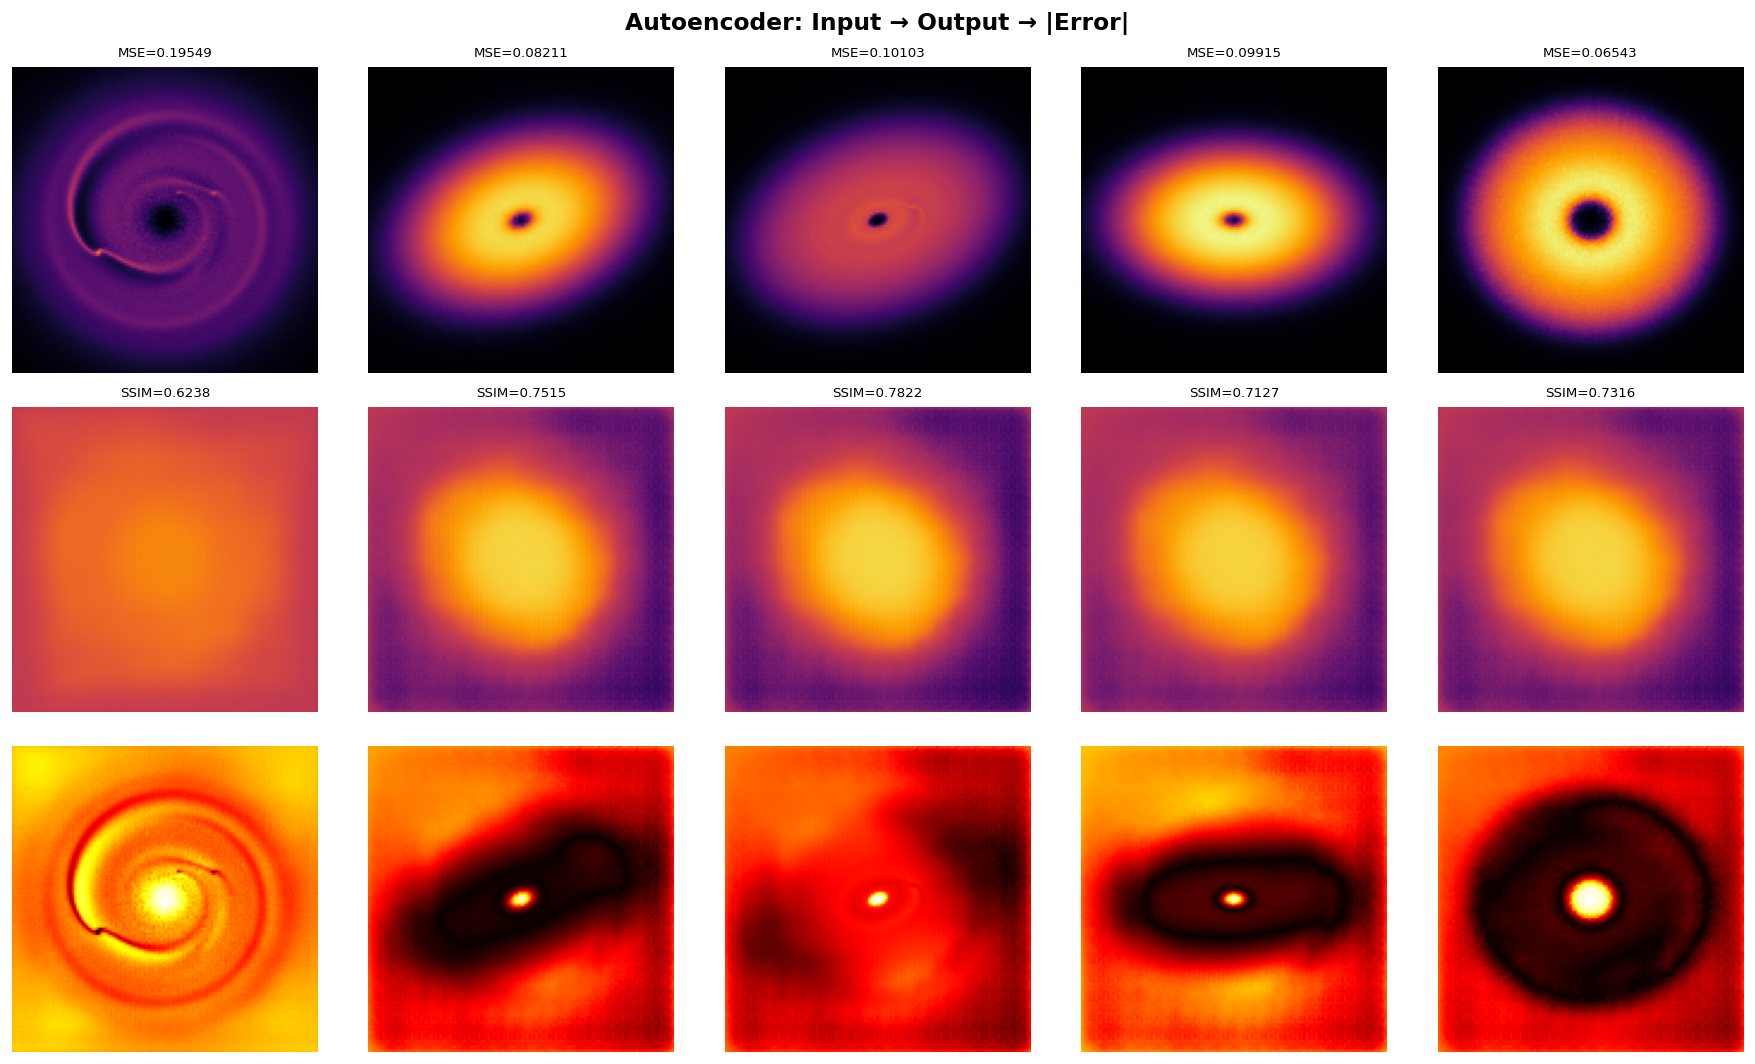

In [10]:
# Input vs Output vs Error
n_show = min(8, len(tm['orig']))
fig, axes = plt.subplots(3, n_show, figsize=(n_show*3, 9), dpi=120)
fig.suptitle('Autoencoder: Input → Output → |Error|', fontsize=14, weight='bold')
idx = np.random.choice(len(tm['orig']), n_show, replace=False)
for i, j in enumerate(idx):
    o = tm['orig'][j,0].numpy(); r = tm['rec'][j,0].numpy()
    axes[0,i].imshow(o, cmap='inferno', origin='lower', vmin=0, vmax=1); axes[0,i].axis('off')
    axes[0,i].set_title(f'MSE={tm["mse"][j]:.5f}', fontsize=8)
    axes[1,i].imshow(r, cmap='inferno', origin='lower', vmin=0, vmax=1); axes[1,i].axis('off')
    s = tm['msssim'][j]; axes[1,i].set_title(f'SSIM={s:.4f}' if not np.isnan(s) else '', fontsize=8)
    axes[2,i].imshow(np.abs(o-r), cmap='hot', origin='lower'); axes[2,i].axis('off')
axes[0,0].set_ylabel('Input', fontsize=11, weight='bold')
axes[1,0].set_ylabel('Output', fontsize=11, weight='bold')
axes[2,0].set_ylabel('|Error|', fontsize=11, weight='bold')
plt.tight_layout(); plt.savefig('reconstruction.png', dpi=150, bbox_inches='tight'); plt.show()

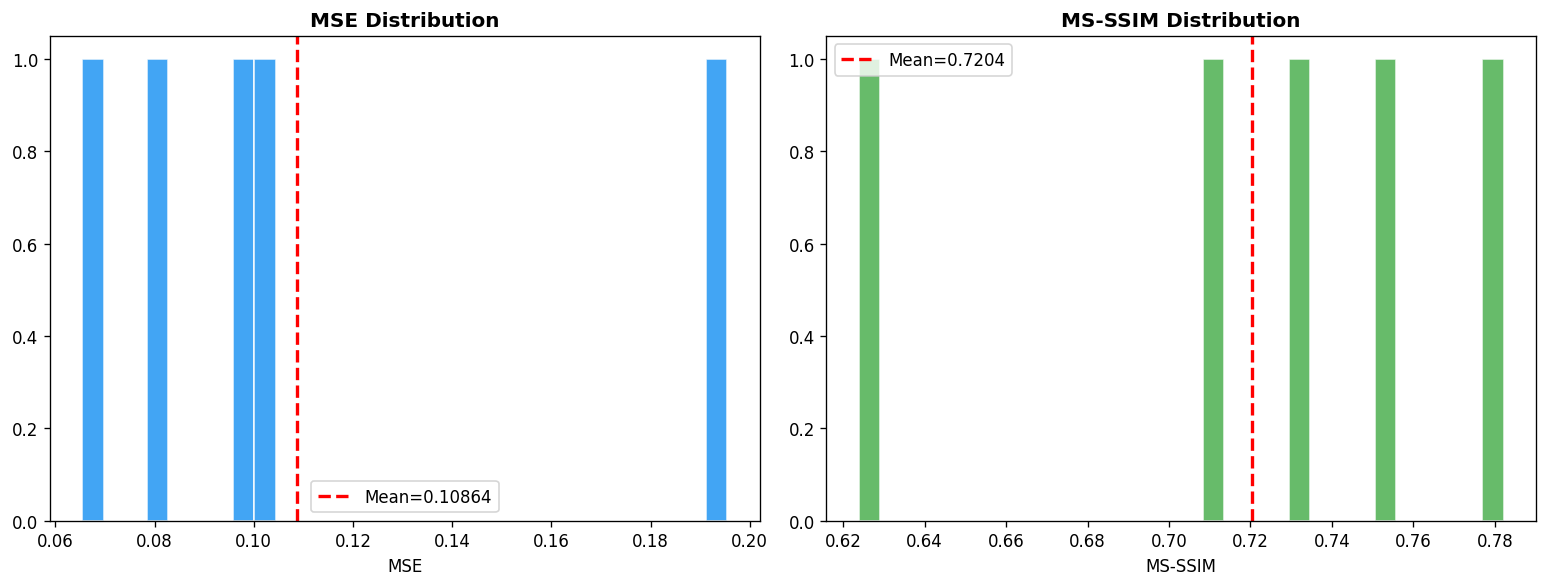

In [11]:
# Metric distributions
fig, (a1,a2) = plt.subplots(1,2,figsize=(13,5),dpi=120)
a1.hist(tm['mse'],bins=30,color='#2196F3',alpha=0.85,edgecolor='w')
a1.axvline(tm['mse'].mean(),color='red',ls='--',lw=2,label=f'Mean={tm["mse"].mean():.5f}')
a1.set_xlabel('MSE'); a1.set_title('MSE Distribution',weight='bold'); a1.legend()
a2.hist(valid_ssim,bins=30,color='#4CAF50',alpha=0.85,edgecolor='w')
a2.axvline(valid_ssim.mean(),color='red',ls='--',lw=2,label=f'Mean={valid_ssim.mean():.4f}')
a2.set_xlabel('MS-SSIM'); a2.set_title('MS-SSIM Distribution',weight='bold'); a2.legend()
plt.tight_layout(); plt.savefig('metrics_dist.png',dpi=150,bbox_inches='tight'); plt.show()

## Latent Space API

Feed in any image, get its latent encoding back.


In [12]:
def encode_image(image_or_path, model=model, device=DEVICE):

    model.eval()
    if isinstance(image_or_path, (str, Path)):
        image = preprocess_image(load_fits_image(str(image_or_path)))
    else:
        image = np.array(image_or_path, dtype=np.float32)
        if image.shape != (IMG_SIZE, IMG_SIZE):
            from scipy.ndimage import zoom
            image = zoom(image, (IMG_SIZE/image.shape[0], IMG_SIZE/image.shape[1]), order=1)
    x = torch.tensor(image).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad(): z = model.encode(x)
    return z.cpu().numpy().flatten()


def decode_latent(z, model=model, device=DEVICE):
    
    model.eval()
    zt = torch.tensor(z, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad(): x_hat = model.decode(zt)
    return x_hat.cpu().numpy()[0, 0]


print('LATENT SPACE API')
print('  z   = encode_image("disk.fits")   # → numpy (128,)')
print('  z   = encode_image(numpy_array)   # → numpy (128,)')
print('  img = decode_latent(z)            # → numpy (128, 128)')

z_demo = encode_image(fits_files[0])
print(f'\nEncoded {os.path.basename(fits_files[0])}:')
print(f'  Shape: {z_demo.shape}')
print(f'  Range: [{z_demo.min():.3f}, {z_demo.max():.3f}]')
print(f'  First 5: {z_demo[:5].round(3)}')

img_rt = decode_latent(z_demo)
print(f'  Decoded shape: {img_rt.shape}')

LATENT SPACE API
  z   = encode_image("disk.fits")   # → numpy (128,)
  z   = encode_image(numpy_array)   # → numpy (128,)
  img = decode_latent(z)            # → numpy (128, 128)

Encoded planet0_00226_1250.fits:
  Shape: (128,)
  Range: [-63.980, 53.790]
  First 5: [41.988  4.597 36.231  8.008 45.731]
  Decoded shape: (128, 128)


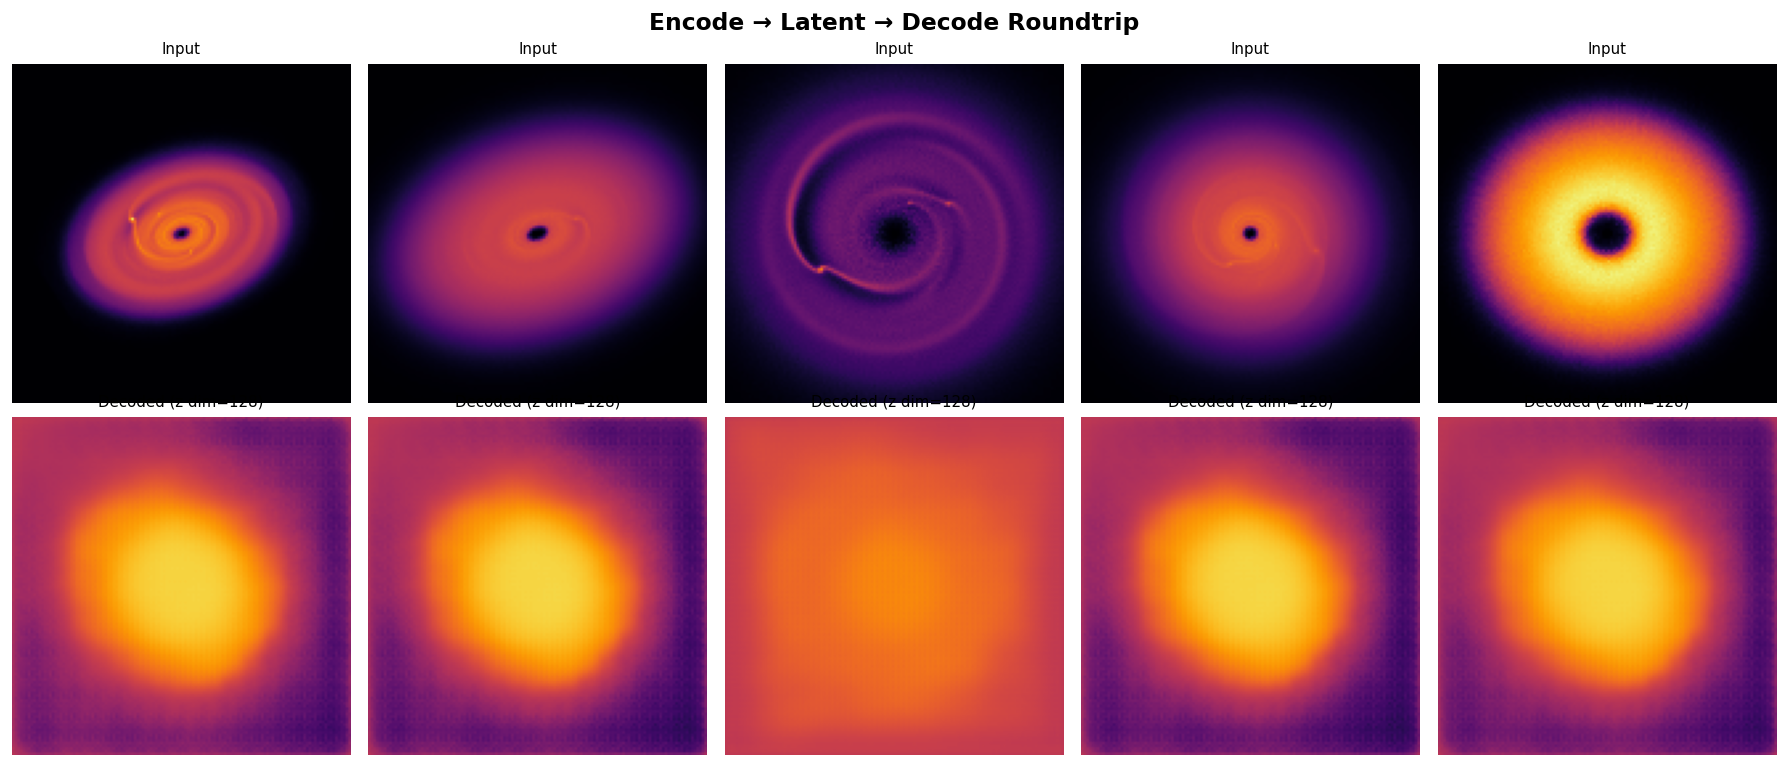

In [13]:
# Encode → Decode roundtrip demo
fig, axes = plt.subplots(2, 5, figsize=(15, 6.5), dpi=120)
fig.suptitle('Encode → Latent → Decode Roundtrip', fontsize=14, weight='bold')
for i in range(5):
    fp = fits_files[i*max(1,len(fits_files)//5)]
    z = encode_image(fp)
    decoded = decode_latent(z)
    original = preprocess_image(load_fits_image(fp))
    axes[0,i].imshow(original, cmap='inferno', origin='lower', vmin=0, vmax=1)
    axes[0,i].set_title(f'Input', fontsize=9); axes[0,i].axis('off')
    axes[1,i].imshow(decoded, cmap='inferno', origin='lower', vmin=0, vmax=1)
    axes[1,i].set_title(f'Decoded (z dim={len(z)})', fontsize=9); axes[1,i].axis('off')
axes[0,0].set_ylabel('Original', fontsize=11, weight='bold')
axes[1,0].set_ylabel('Roundtrip', fontsize=11, weight='bold')
plt.tight_layout(); plt.savefig('roundtrip.png', dpi=150, bbox_inches='tight'); plt.show()

## Inference Pipeline


In [14]:
def run_inference(fits_dir, model_path='best_autoencoder.pt', device=DEVICE):

    mdl = DiskAutoencoder().to(device)
    mdl.load_state_dict(torch.load(model_path, map_location=device)); mdl.eval()
    files = sorted(glob.glob(os.path.join(fits_dir, '**/*.fits'), recursive=True))
    if not files: files = sorted(glob.glob(os.path.join(fits_dir, '*.fits')))
    print(f'Found {len(files)} files')
    imgs, fnames, latents, recs = [], [], [], []
    for fp in tqdm(files, desc='Inference'):
        try:
            proc = preprocess_image(load_fits_image(fp))
            imgs.append(proc); fnames.append(os.path.basename(fp))
            x = torch.tensor(proc).unsqueeze(0).unsqueeze(0).to(device)
            with torch.no_grad(): rec, z = mdl(x)
            latents.append(z.cpu().numpy().flatten()); recs.append(rec.cpu().numpy()[0,0])
        except Exception as e: print(f'  Skip {fp}: {e}')
    return {'images': np.array(imgs), 'filenames': fnames,
            'latents': np.array(latents), 'reconstructions': np.array(recs)}

print('Pipeline ready: results = run_inference("./new_data/")')

Pipeline ready: results = run_inference("./new_data/")


## Export


In [15]:
torch.save(model.state_dict(), 'best_autoencoder.pt')
summary = {'task': 'EXXA4 Image-Based Test — Autoencoder', 'author': 'Abdellah Elmlih',
    'architecture': 'Conv AE with skip connections',
    'latent_dim': LATENT_DIM, 'params': n_params, 'epochs': N_EPOCHS,
    'test_mse': float(tm['mse'].mean()), 'test_msssim': float(valid_ssim.mean())}
with open('image_test_summary.json', 'w') as f: json.dump(summary, f, indent=2)
print('Saved: best_autoencoder.pt, image_test_summary.json')
print(json.dumps(summary, indent=2))

Saved: best_autoencoder.pt, image_test_summary.json
{
  "task": "EXXA4 Image-Based Test \u2014 Autoencoder",
  "author": "Abdellah Elmlih",
  "architecture": "Conv AE with skip connections",
  "latent_dim": 128,
  "params": 18682881,
  "epochs": 80,
  "test_mse": 0.10864205062389373,
  "test_msssim": 0.7203567743301391
}


## References

- Terry et al. (2022)
- Wang et al. (2003) — MS-SSIM
